In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling1D,
    LSTM
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [2]:
FS = 250

CHANNELS = [
    "FZ",
    "C3",
    "CZ",
    "C4"
]

RANDOM_STATE = 42

MANIFEST_PATH = Path(
    "../../data/Processed/final_clean_manifest.csv"
)

FINAL_DATA_DIR = Path(
    "../../data/Processed/final_clean_trials"
)

## Loading dataset

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Total trials:", len(manifest))
print()
print(manifest["label"].value_counts())

display(manifest.head())

Total trials: 1935

label
right    971
left     964
Name: count, dtype: int64


,trial_id,file_path,label
0,1,..\..\data\Processed\final_clean_trials\cellul...,left
1,2,..\..\data\Processed\final_clean_trials\cellul...,right
2,3,..\..\data\Processed\final_clean_trials\cellul...,left
3,4,..\..\data\Processed\final_clean_trials\cellul...,left
4,5,..\..\data\Processed\final_clean_trials\cellul...,left


In [4]:
def load_eeg_data(manifest):
    X = []
    y = []

    for _, row in manifest.iterrows():

        trial_id = int(row["trial_id"])

        file_path = (
            FINAL_DATA_DIR
            / f"cellula_MI_data_{trial_id}.csv"
        )

        df = pd.read_csv(file_path)

        trial = df[CHANNELS].values

        X.append(trial)
        y.append(row["label"].lower())

    return np.array(X), np.array(y)


X, y_text = load_eeg_data(manifest)

print("X shape:", X.shape)
print(
    "Labels:",
    np.unique(y_text, return_counts=True)
)

X shape: (1935, 2500, 4)
Labels: (array(['left', 'right'], dtype='<U5'), array([964, 971]))


## Encoding 

In [5]:
y = pd.Series(y_text).map({
    "left": 0,
    "right": 1
}).to_numpy()

print(
    np.unique(
        y,
        return_counts=True
    )
)

(array([0, 1]), array([964, 971]))


## Split train / validation / test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (1238, 2500, 4)
Val  : (310, 2500, 4)
Test : (387, 2500, 4)


In [7]:
train_mean = X_train.mean(
    axis=(0, 1),
    keepdims=True
)

train_std = X_train.std(
    axis=(0, 1),
    keepdims=True
)

train_std = np.where(
    train_std == 0,
    1,
    train_std
)

X_train_norm = (
    X_train - train_mean
) / train_std

X_val_norm = (
    X_val - train_mean
) / train_std

X_test_norm = (
    X_test - train_mean
) / train_std

In [8]:
print("Train mean:", X_train_norm.mean())
print("Train std :", X_train_norm.std())

print("NaNs:", np.isnan(X_train_norm).sum())
print("Inf :", np.isinf(X_train_norm).sum())

Train mean: -3.114909156314391e-17
Train std : 1.000000000000008
NaNs: 0
Inf : 0


## CNN bulid

In [9]:
def build_cnn(
    n_samples=2500,
    n_channels=4
):

    inputs = Input(
        shape=(n_samples, n_channels)
    )

    x = Conv1D(
        32,
        kernel_size=15,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = MaxPooling1D(
        pool_size=4
    )(x)

    x = Dropout(0.3)(x)

    x = Conv1D(
        64,
        kernel_size=9,
        padding="same",
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    x = MaxPooling1D(
        pool_size=4
    )(x)

    x = Dropout(0.4)(x)

    x = Conv1D(
        128,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(x)

    x = GlobalAveragePooling1D()(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        inputs=inputs,
        outputs=outputs
    )

In [10]:
tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

cnn_model = build_cnn(
    n_samples=X_train_norm.shape[1],
    n_channels=X_train_norm.shape[2]
)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2500, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2500, 32)       │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 625, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 156, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 156, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 156, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,049 (242.38 KB)

 Trainable params: 61,857 (241.63 KB)

 Non-trainable params: 192 (768.00 B)

In [11]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

## Training

In [12]:
cnn_history = cnn_model.fit(
    X_train_norm,
    y_train,

    validation_data=(
        X_val_norm,
        y_val
    ),

    epochs=100,
    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.5032 - loss: 0.7439 - val_accuracy: 0.5032 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.5008 - loss: 0.7189 - val_accuracy: 0.4968 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5121 - loss: 0.7036 - val_accuracy: 0.4903 - val_loss: 0.7005 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.4984 - loss: 0.7044 - val_accuracy: 0.4935 - val_loss: 0.6999 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.5089 - loss: 0.7014 - val_accuracy: 0.5000 - val_loss: 0.6991 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.5186 - loss: 0.6925 - val_accuracy: 0.5129 - val_loss: 0.6964 - learning_rate: 0.0010
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.5186 - loss: 0.6939 - 

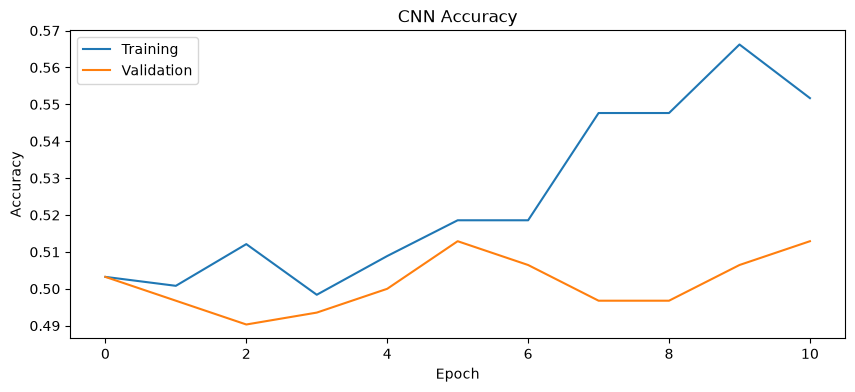

In [13]:
plt.figure(figsize=(10, 4))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()

plt.show()

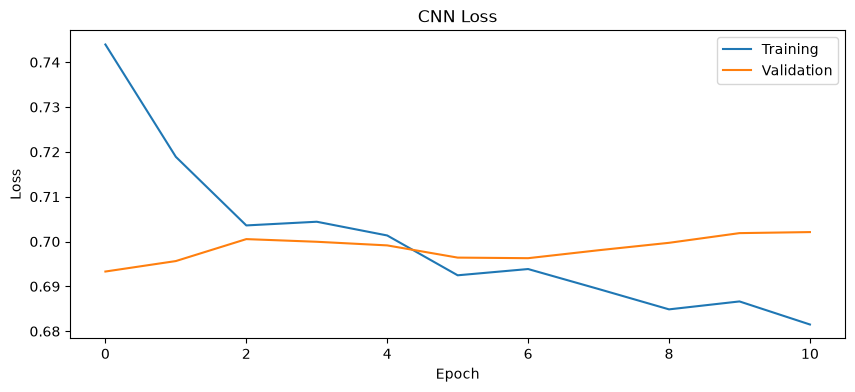

In [14]:
plt.figure(figsize=(10, 4))

plt.plot(
    cnn_history.history["loss"],
    label="Training"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()

plt.show()

### include LSTM

In [15]:
def build_cnn_lstm(
    n_samples=2500,
    n_channels=4
):

    inputs = Input(
        shape=(n_samples, n_channels)
    )

    x = Conv1D(
        32,
        kernel_size=15,
        padding="same",
        activation="relu"
    )(inputs)

    x = BatchNormalization()(x)

    x = MaxPooling1D(
        pool_size=4
    )(x)

    x = Dropout(0.3)(x)

    x = Conv1D(
        64,
        kernel_size=9,
        padding="same",
        activation="relu"
    )(x)

    x = BatchNormalization()(x)

    x = MaxPooling1D(
        pool_size=4
    )(x)

    x = Dropout(0.3)(x)

    x = LSTM(
        64,
        return_sequences=False
    )(x)

    x = Dropout(0.5)(x)

    outputs = Dense(
        1,
        activation="sigmoid"
    )(x)

    return Model(
        inputs=inputs,
        outputs=outputs
    )

In [16]:
tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

cnn_lstm_model = build_cnn_lstm(
    n_samples=X_train_norm.shape[1],
    n_channels=X_train_norm.shape[2]
)

cnn_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2500, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2500, 32)       │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 625, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 625, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 625, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 156, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 156, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,921 (210.63 KB)

 Trainable params: 53,729 (209.88 KB)

 Non-trainable params: 192 (768.00 B)

In [17]:
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_norm,
    y_train,

    validation_data=(
        X_val_norm,
        y_val
    ),

    epochs=100,
    batch_size=32,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )
    ],

    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.5113 - loss: 0.7285 - val_accuracy: 0.5258 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.5258 - loss: 0.7157 - val_accuracy: 0.5097 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.5137 - loss: 0.7164 - val_accuracy: 0.4871 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.5194 - loss: 0.7025 - val_accuracy: 0.4968 - val_loss: 0.6967 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.5186 - loss: 0.7019 - val_accuracy: 0.5065 - val_loss: 0.7027 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.5565 - loss: 0.6886 - val_accuracy: 0.4935 - val_loss: 0.7078 - learning_rate: 0.0010
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.5565 - loss: 0.

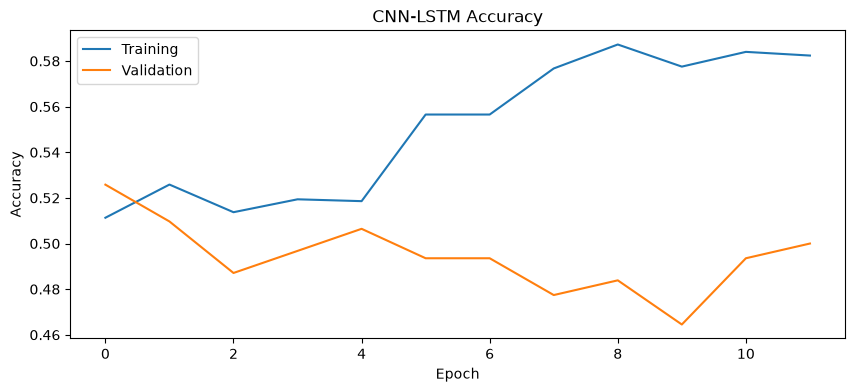

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    cnn_lstm_history.history["accuracy"],
    label="Training"
)

plt.plot(
    cnn_lstm_history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN-LSTM Accuracy")
plt.legend()

plt.show()

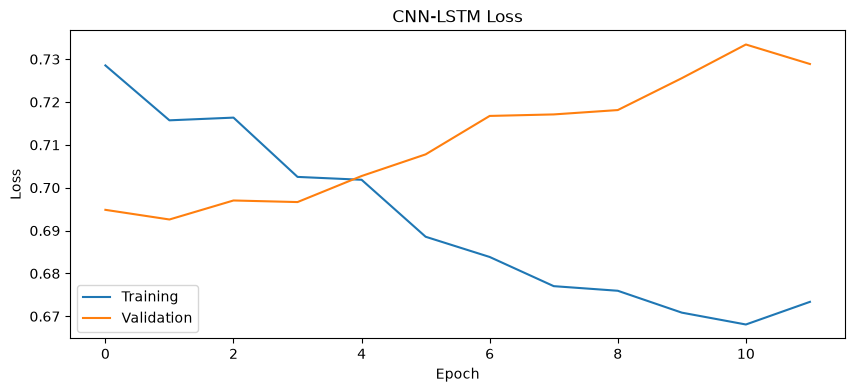

In [19]:
plt.figure(figsize=(10, 4))

plt.plot(
    cnn_lstm_history.history["loss"],
    label="Training"
)

plt.plot(
    cnn_lstm_history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM Loss")
plt.legend()

plt.show()

In [20]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(
    X_val_norm,
    y_val,
    verbose=0
)

lstm_val_loss, lstm_val_acc = cnn_lstm_model.evaluate(
    X_val_norm,
    y_val,
    verbose=0
)

print(
    f"CNN validation accuracy: "
    f"{cnn_val_acc * 100:.2f}%"
)

print(
    f"CNN-LSTM validation accuracy: "
    f"{lstm_val_acc * 100:.2f}%"
)

CNN validation accuracy: 50.32%
CNN-LSTM validation accuracy: 50.97%


In [21]:
if cnn_val_acc >= lstm_val_acc:
    best_model = cnn_model
    best_name = "CNN"
else:
    best_model = cnn_lstm_model
    best_name = "CNN-LSTM"

print("Selected model:", best_name)

Selected model: CNN-LSTM


In [22]:
y_prob = best_model.predict(
    X_test_norm
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [23]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

print("Model:", best_name)

print(
    f"Test accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Balanced accuracy: "
    f"{test_balanced_accuracy * 100:.2f}%"
)

Model: CNN-LSTM
Test accuracy: 54.26%
Balanced accuracy: 54.26%


In [24]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "LEFT",
            "RIGHT"
        ]
    )
)

              precision    recall  f1-score   support

        LEFT       0.54      0.52      0.53       193
       RIGHT       0.54      0.57      0.55       194

    accuracy                           0.54       387
   macro avg       0.54      0.54      0.54       387
weighted avg       0.54      0.54      0.54       387



In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[100  93]
 [ 84 110]]
